<a href="https://colab.research.google.com/github/kanishk22997-art/E-commercesales-analysis/blob/main/E_commerce2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

data = {
    "Order_ID": [1001,1002,1003,1004,1005,1006,1007,1008,1009,1010,1011,1012,1013,1014,1015,1016],
    "Customer_ID": ["C001","C002","C003","C001","C004","C005","C002","C006","C007","C008","C009","C010","C011","C012","C013","C014"],
    "Product": ["Laptop","Mobile","Shoes","Headphones","T-Shirt","Refrigerator","Microwave","Watch","Tablet","Air Conditioner","Jeans","Camera","Sofa","Chair","Bed","Blender"],
    "Category": ["Electronics","Electronics","Fashion","Electronics","Fashion","Appliances","Appliances","Fashion","Electronics","Appliances","Fashion","Electronics","Home","Home","Home","Appliances"],
    "Order_Date": ["2025-01-05","2025-01-10","2025-01-15","2025-02-01","2025-02-10","2025-02-20","2025-03-05","2025-03-12","2025-03-18","2025-04-02","2025-04-10","2025-04-15","2025-01-07","2025-02-14","2025-03-22","2025-04-18"],
    "Sales": [55000,20000,3000,2000,1500,30000,12000,5000,25000,40000,2500,45000,20000,5000,30000,3000],
    "Quantity": [1,2,1,1,3,1,1,2,1,1,2,1,1,2,1,1],
    "Region": ["North","West","South","North","East","West","South","North","East","West","South","North","East","West","North","South"]
}

df = pd.DataFrame(data)

df.to_csv("ecommerce2.csv", index=False)

print("CSV file created successfully")

CSV file created successfully


In [4]:
df = pd.read_csv ('ecommerce2.csv')
print (df)

    Order_ID Customer_ID          Product     Category  Order_Date  Sales  \
0       1001        C001           Laptop  Electronics  2025-01-05  55000   
1       1002        C002           Mobile  Electronics  2025-01-10  20000   
2       1003        C003            Shoes      Fashion  2025-01-15   3000   
3       1004        C001       Headphones  Electronics  2025-02-01   2000   
4       1005        C004          T-Shirt      Fashion  2025-02-10   1500   
5       1006        C005     Refrigerator   Appliances  2025-02-20  30000   
6       1007        C002        Microwave   Appliances  2025-03-05  12000   
7       1008        C006            Watch      Fashion  2025-03-12   5000   
8       1009        C007           Tablet  Electronics  2025-03-18  25000   
9       1010        C008  Air Conditioner   Appliances  2025-04-02  40000   
10      1011        C009            Jeans      Fashion  2025-04-10   2500   
11      1012        C010           Camera  Electronics  2025-04-15  45000   

   Total_Revenue
0         299000


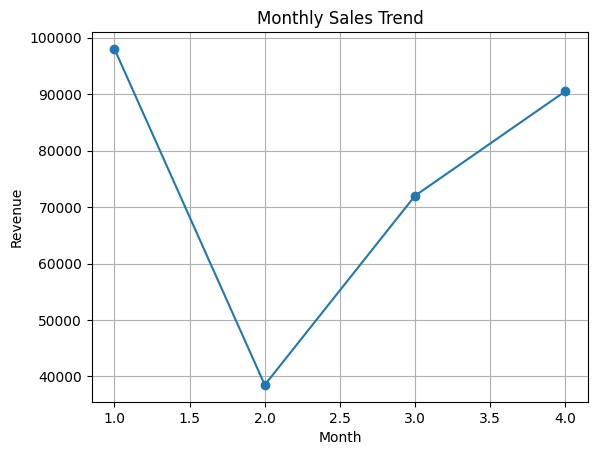

           Product  Revenue
0           Laptop    55000
1           Camera    45000
2  Air Conditioner    40000
3     Refrigerator    30000
4              Bed    30000


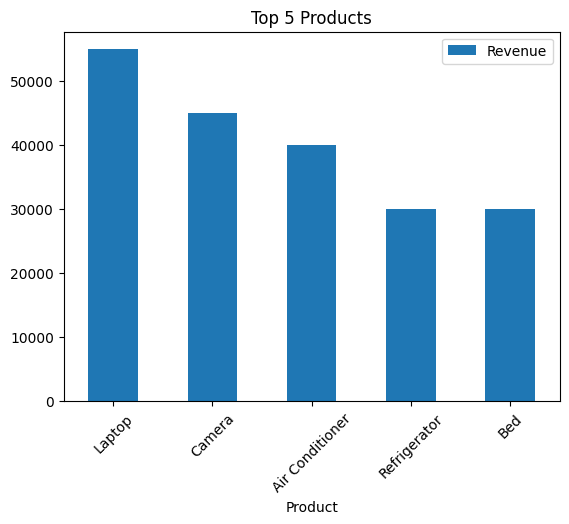

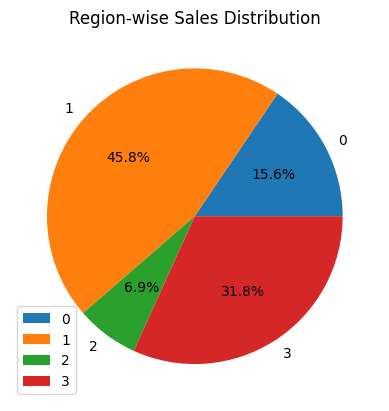

In [6]:

import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

df = pd.read_csv('ecommerce2.csv')

conn = sqlite3.connect('ecommerce2.db')
df.to_sql('orders', conn, if_exists='replace', index=False)

query1 = "SELECT SUM(Sales) AS Total_Revenue FROM orders"
print(pd.read_sql(query1, conn))

df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Month'] = df['Order_Date'].dt.month

monthly = df.groupby('Month')['Sales'].sum()

monthly.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid()
plt.show()

query2 = """
SELECT Product, SUM(Sales) AS Revenue
FROM orders
GROUP BY Product
ORDER BY Revenue DESC
LIMIT 5
"""
top_products = pd.read_sql(query2, conn)
print(top_products)

top_products.plot(kind='bar', x='Product', y='Revenue')
plt.title("Top 5 Products")
plt.xticks(rotation=45)
plt.show()

query3 = """
SELECT Region, SUM(Sales) AS Revenue
FROM orders
GROUP BY Region
"""
region_sales = pd.read_sql(query3, conn)

region_sales.plot(kind='pie', y='Revenue', autopct='%1.1f%%')
plt.title("Region-wise Sales Distribution")
plt.ylabel('')
plt.show()